## Validation of NMWI


In [90]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib
matplotlib.use("cairo")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [2]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Final_Codes


In [3]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)

Found 28 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1807, and number of taxa: 294
Number of unique studies: 28

Sample_id per Category:
Category  n_sample_id
    case         1122
 control          685


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

In [4]:
X_new = X.copy()

In [5]:
%run -i Codes/Auxiliary_files/NMWI.py # Run model

NMWI fitted; 10x10cv


In [6]:
###### RESULTS SUMMARY
print(f"10x10 CV BA: {scores.mean():.4f}") #print(f"10x10 CV SD: {scores.std():.4f}")
print(f"C: {C:.4f}")
print(f"Train ba: {train_bal_acc:.4f}")
print(f"# positive coefs: {num_pos}, # negative coefs: {num_neg}, # zero coefs: {num_zero}")

10x10 CV BA: 0.7382
C: 0.7950
Train ba: 0.7483
# positive coefs: 13, # negative coefs: 10, # zero coefs: 271


## Figure 5.a

In [7]:
%%writefile Codes/Auxiliary_files/Generate_data_val.py
# Load metadata
file_path_validation = 'Data/Supplementary_table1.xlsx'
df_validation = pd.read_excel(file_path_validation, sheet_name='Validation')

sra_data_validation = pd.read_excel(file_path_validation, sheet_name='SRA_validation')
sra_data_validation = sra_data_validation[['Sample_id', 'BioProject.Number', 'Category', 'Disease']]

def read_genus_table(path):
    with open(path, 'r', encoding='utf-8') as f: 
        lines_validation = f.readlines()

    header_idx_validation = next((i for i,l in enumerate(lines_validation) if l.lstrip().startswith('#OTU ID')), None)
    header_validation = lines_validation[header_idx_validation].lstrip('#').strip().split('\t')
    table_data_validation = pd.read_csv(path, sep='\t', header=None, names=header_validation, skiprows=header_idx_validation+1, dtype=str)

    for c in table_data_validation.columns:
        if c != 'OTU ID': table_data_validation[c] = pd.to_numeric(table_data_validation[c], errors='coerce')
    return table_data_validation

paths_validation = sorted(glob.glob(os.path.join('Feature_tables', '**', '*_final_table_depth.tsv'), recursive=True))
allowed_projects_validation = set(df_validation["BioProject.Number"].dropna().astype(str))
filtered_files_validation = [f for f in paths_validation if os.path.basename(f).split("_")[2] in allowed_projects_validation]

print(f"Found {len(filtered_files_validation)} genus tables in validation")

# CREATE ALL GENUS TABLES MERGED
merged_validation = None
for p in filtered_files_validation:
    table_data_validation = read_genus_table(p)
    sample_cols_validation = [c for c in table_data_validation.columns if c != 'OTU ID']
    if merged_validation is not None:
        dupes_validation = set(sample_cols_validation) & set([c for c in merged_validation.columns if c != 'OTU ID'])
        if dupes_validation: 
            raise ValueError(f"Duplicate sample IDs found: {dupes_validation} in {p}")
        merged_validation = merged_validation.merge(table_data_validation, on='OTU ID', how='outer')
    else: 
        merged_validation = table_data_validation.copy()

for c in merged_validation.columns:
    if c != 'OTU ID': 
        merged_validation[c] = pd.to_numeric(merged_validation[c], errors='coerce').fillna(0.0)
sample_cols_validation = [c for c in merged_validation.columns if c != 'OTU ID']
merged_validation = merged_validation[['OTU ID'] + sorted(sample_cols_validation)]

merged_validation["OTU ID"] = merged_validation["OTU ID"].apply(simplify_taxonomy)
merged_validation = merged_validation.groupby("OTU ID", as_index=False).sum(numeric_only=True)

ra_validation = merged_validation.set_index('OTU ID').copy() 

filtered_t_val = ra_validation.T.reset_index()
filtered_t_val.rename(columns={'index': 'Sample_id'}, inplace=True)

# === Merge metadata ===
validation_meta = filtered_t_val.merge(sra_data_validation, on='Sample_id', how='left')
validation_meta = validation_meta.merge(df_validation, on='BioProject.Number', how='left')
validation_meta = validation_meta[validation_meta["Sample_id"].isin(sra_data_validation["Sample_id"])]

meta_cols = [c for c in validation_meta.columns if not c.startswith("d__")]
taxa_cols = [c for c in validation_meta.columns if c.startswith("d__")]

n_t, n_s = validation_meta.shape
print(f"Number of samples: {n_t}, and number of taxa: {len(taxa_cols)}")
print(f"Number of unique studies: {validation_meta['BioProject.Number'].nunique()}")

validation_set = validation_meta.set_index(['BioProject.Number', 'Sample_id']) # multi indexed table
X_val = validation_set[[c for c in validation_set.columns if c.startswith("d__")]]
# Relative abundance!
X_val = X_val.div(X_val.sum(axis=1), axis=0) # manually checked
y_val = validation_set["Category"].map({'case': False, 'control': True})


Overwriting Codes/Auxiliary_files/Generate_data_val.py


In [8]:
%run -i Codes/Auxiliary_files/Generate_data_val.py # Run model

Found 11 genus tables in validation
Number of samples: 350, and number of taxa: 1626
Number of unique studies: 11


In [9]:
# Count sample_id per Category in merged_meta
samples_per_category = (
    validation_meta.groupby("Category")["Sample_id"]
    .nunique()              # use .count() if you want raw row counts instead
    .reset_index(name="n_sample_id")
    .sort_values("n_sample_id", ascending=False)
)

print("\nSample_id per Category:")
print(samples_per_category.to_string(index=False))


Sample_id per Category:
Category  n_sample_id
    case          241
 control          109


In [10]:
globals().update(vars_dict)

# Apply the same transformation
X_val_transform = X_val.copy()
# Align validation features to training features
train_features = list(NMWI.feature_names_in_)
missing = set(train_features) - set(X_val_transform.columns)

for f in missing:
    X_val_transform[f] = 0

X_aligned = X_val_transform[train_features]

# Validation decision scores
NMWI_scores = pd.Series(
    NMWI.decision_function(X_aligned),
    index=X_aligned.index,
    name="NMWI"
)
print(f"Validation ba: {balanced_accuracy_score(y_val, NMWI_scores > 0):.4f}")

Validation ba: 0.7094


### NMWI

In [103]:
meta_val = validation_meta.reset_index()[["Category", "Disease", "BioProject.Number", "Citation"]].copy()
meta_val["NMWI"] = NMWI_scores.to_numpy().ravel()

meta_val["Category"] = meta_val["Category"].astype(str)
meta_val["Disease"] = meta_val["Disease"].astype(str)
meta_val["BioProject.Number"] = meta_val["BioProject.Number"].astype(str)
meta_val["Citation"] = meta_val["Citation"].astype(str)

# safer label in case citations repeat across BioProjects
meta_val["Study_Label"] = meta_val["Citation"] + "\n(" + meta_val["BioProject.Number"] + ")"

cases = meta_val.query("Category == 'case'").copy()
controls = meta_val.query("Category == 'control'").copy()

ylim = 2.5

case_order_label = cases.groupby("BioProject.Number")["NMWI"].median().sort_values(ascending=False).index.map(
    cases.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]).tolist()

control_order_label = controls.groupby("BioProject.Number")["NMWI"].median().sort_values(ascending=False).index.map(
    controls.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]).tolist()


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    dpi=300,
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 4, 2.7]}
)

# Panel 1: overall validation
sns.violinplot(
    data=meta_val,
    x="Category",
    y="NMWI",
    order=["control", "case"],
    color="lightgray",
    inner=None,
    ax=axes[0],
    cut = 0
)
sns.boxplot(
    data=meta_val,
    x="Category",
    y="NMWI",
    order=["control", "case"],
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[0]
)
axes[0].set(title="NMWI Validation", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)

# Panel 2: case studies
sns.violinplot(
    data=cases,
    x="Study_Label",
    y="NMWI",
    order=case_order_label,
    color="lightcoral",
    inner=None,
    width=1.1,
    ax=axes[1],
    cut = 0
)
sns.boxplot(
    data=cases,
    x="Study_Label",
    y="NMWI",
    order=case_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[1]
)
axes[1].set(title="Cases", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)

# Panel 3: control studies
sns.violinplot(
    data=controls,
    x="Study_Label",
    y="NMWI",
    order=control_order_label,
    color="lightblue",
    inner=None,
    width=1.1,
    ax=axes[2],
    cut = 0
)
sns.boxplot(
    data=controls,
    x="Study_Label",
    y="NMWI",
    order=control_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[2]
)
axes[2].set(title="Controls", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[2].tick_params(axis="x", rotation=45)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig('Figures/Fig5a.pdf')
plt.show()


In [97]:
meta_val.groupby('Disease')['BioProject.Number'].unique()

Disease
COVID19                              [PRJNA745169, PRJNA744167]
Cystic Fibrosis                       [PRJEB31332, PRJNA374847]
Healthy               [PRJNA746950, PRJNA1024520, PRJNA1213741]
NK/T-Cell Lymphoma                                [PRJNA733573]
OS                                                [PRJNA930496]
RTI                                   [PRJEB28612, PRJNA596902]
Name: BioProject.Number, dtype: object

In [102]:
meta_val.reset_index().groupby('Disease')['index'].count()

Disease
COVID19                88
Cystic Fibrosis        11
Healthy                59
NK/T-Cell Lymphoma     27
OS                     59
RTI                   106
Name: index, dtype: int64

In [68]:
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta

# keep only what we need
sub = meta_val[["Category", "NMWI"]].dropna().copy()

case_vals = sub.loc[sub["Category"] == "case", "NMWI"]
control_vals = sub.loc[sub["Category"] == "control", "NMWI"]

u, pval = mannwhitneyu(cases['NMWI'], controls['NMWI'], alternative="two-sided")
cliffs_delta = (2 * u) / (len(case_vals) * len(control_vals)) - 1

results = pd.DataFrame([{
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(case_vals),
    "N_2": len(control_vals),
    "Cliffs_delta": cliffs_delta,
    "MannWhitney_p": pval
}])

# verified with: d, res = cliffs_delta(cases['NMWI'],controls['NMWI'])
results


,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,case,control,241,109,-0.600594,2.283017e-19


In [69]:
temp_p496 = meta_val.loc[meta_val['BioProject.Number']=='PRJNA930496']
case_mw = temp_p496.query("Category == 'case'")['NMWI']
control_mw = temp_p496.query("Category == 'control'")['NMWI']
u, pval = mannwhitneyu(case_mw, control_mw, alternative="two-sided")
print(f"pval: {pval}")
print(cliffs_delta(case_mw, control_mw))

temp_p169 = meta_val.loc[meta_val['BioProject.Number']=='PRJNA745169']
case_mw = temp_p169.query("Category == 'case'")['NMWI']
control_mw = temp_p169.query("Category == 'control'")['NMWI']
u, pval = mannwhitneyu(case_mw, control_mw, alternative="two-sided")
print(f"pval: {pval}")
print(cliffs_delta(case_mw, control_mw))

pval: 7.662722865631792e-08


TypeError: 'numpy.float64' object is not callable

In [70]:
from scipy.stats import mannwhitneyu
import pandas as pd

# pooled healthy samples
healthy_vals = (
    meta_val.loc[meta_val["Category"] == "control", "NMWI"]
    .dropna()
)

results = []

case_projects = (
    meta_val.loc[meta_val["Category"] == "case", "BioProject.Number"]
    .dropna()
    .astype(str)
    .unique()
)

for project in case_projects:
    case_vals = (
        meta_val.loc[
            (meta_val["Category"] == "case") &
            (meta_val["BioProject.Number"].astype(str) == project),
            "NMWI"
        ]
        .dropna()
    )

    if len(case_vals) == 0 or len(healthy_vals) == 0:
        continue

    u, pval = mannwhitneyu(case_vals, healthy_vals, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(case_vals) * len(healthy_vals)) - 1

    results.append({
        "BioProject.Number": project,
        "N_case": len(case_vals),
        "N_healthy": len(healthy_vals),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Case_median_NMWI": case_vals.median(),
        "Healthy_median_NMWI": healthy_vals.median()
    })

bioproject_vs_healthy = pd.DataFrame(results).sort_values("MannWhitney_p")
bioproject_vs_healthy


,BioProject.Number,N_case,N_healthy,Cliffs_delta,MannWhitney_p,Case_median_NMWI,Healthy_median_NMWI
6,PRJNA930496,41,109,-0.914970,6.729619e-18,-0.761674,0.223933
4,PRJNA745169,45,109,-0.660754,1.226122e-10,-0.372436,0.223933
7,PRJNA374847,7,109,-0.973788,5.661893e-09,-4.458763,0.223933
2,PRJNA596902,69,109,-0.479325,7.449187e-08,-0.292663,0.223933
3,PRJNA733573,27,109,-0.542644,1.339838e-05,-0.346647,0.223933
0,PRJEB28612,37,109,-0.372675,7.281264e-04,-0.113974,0.223933
5,PRJNA744167,11,109,-0.609675,9.015773e-04,-0.353772,0.223933
1,PRJEB31332,4,109,-0.614679,3.453533e-02,-0.345763,0.223933


In [104]:
# pooled case samples
case_vals_pooled = (
    meta_val.loc[meta_val["Category"] == "case", "NMWI"]
    .dropna()
)

results = []

healthy_projects = (
    meta_val.loc[meta_val["Category"] == "control", "BioProject.Number"]
    .dropna()
    .astype(str)
    .unique()
)

for project in healthy_projects:
    healthy_vals = (
        meta_val.loc[
            (meta_val["Category"] == "control") &
            (meta_val["BioProject.Number"].astype(str) == project),
            "NMWI"
        ]
        .dropna()
    )

    if len(healthy_vals) == 0 or len(case_vals_pooled) == 0:
        continue

    u, pval = mannwhitneyu(healthy_vals, case_vals_pooled, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(healthy_vals) * len(case_vals_pooled)) - 1

    results.append({
        "BioProject.Number": project,
        "N_healthy": len(healthy_vals),
        "N_case": len(case_vals_pooled),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Healthy_median_NMWI": healthy_vals.median(),
        "Case_median_NMWI": case_vals_pooled.median()
    })

healthy_bioproject_vs_cases = pd.DataFrame(results).sort_values("MannWhitney_p")
healthy_bioproject_vs_cases

,BioProject.Number,N_healthy,N_case,Cliffs_delta,MannWhitney_p,Healthy_median_NMWI,Case_median_NMWI
2,PRJNA746950,18,241,0.905486,1.507922e-10,0.702591,-0.379298
4,PRJNA1024520,19,241,0.768945,2.447548e-08,0.445609,-0.379298
1,PRJNA744167,4,241,0.956432,1.142850e-05,0.542832,-0.379298
5,PRJNA1213741,22,241,0.560543,1.364351e-05,0.119767,-0.379298
0,PRJNA745169,28,241,0.372555,1.261231e-03,-0.199648,-0.379298
3,PRJNA930496,18,241,0.442600,1.749787e-03,-0.121354,-0.379298


### Diversity index

In [105]:
# Shannon index 
from scipy.stats import entropy

# prev = ((X_val>0).sum(axis=0)/X_val.shape[0]).T
# keep_taxa_val = prev[prev >= 0.05].index
# ra_sub_val = X_val.T.loc[keep_taxa_val]

filtered = pd.DataFrame({
    'Shannon': X_val.T.apply(lambda x: entropy(x[x > 0], base=np.e),axis=0),
    'Chao1': (X_val.T > 0).sum(axis=0)
        })

filtered.index.name = "Sample_id"
filtered = filtered.merge(sra_data_validation, on='Sample_id', how='left')
# filtered = filtered.set_index(['BioProject.Number', 'Sample_id'])

filtered["Category"] = filtered["Category"].astype(str)
filtered["Disease"] = filtered["Disease"].astype(str)
filtered["BioProject.Number"] = filtered["BioProject.Number"].astype(str)

print(filtered.groupby("Category")['Shannon'].mean())
print(filtered.groupby("Category")['Chao1'].mean())

meta_diversity = filtered.copy()

cases = meta_diversity.query("Category == 'case'")
controls = meta_diversity.query("Category == 'control'")

plot_df_disease = pd.DataFrame({
    "Group": pd.concat(
        [pd.Series(["All controls"] * len(controls)), cases["Disease"]],
        ignore_index=True
    ),
    "Shannon": pd.concat(
        [controls["Shannon"], cases["Shannon"]],
        ignore_index=True
    ),
        "Chao1": pd.concat(
        [controls["Chao1"], cases["Chao1"]],
        ignore_index=True
    )
})


Category
case       1.429646
control    1.586325
Name: Shannon, dtype: float64
Category
case       33.589212
control    42.972477
Name: Chao1, dtype: float64


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

sns.violinplot(
    data=meta_diversity,
    x="Category",
    y="Shannon",
    order=["control", "case"],
    color="lightgray",
    ax=axes[0]
)
axes[0].set(title="Shannon Validation", xlabel="", ylabel="Shannon Index")

sns.violinplot(
    data=plot_df_disease,
    x="Group",
    y="Shannon",
    order=["All controls"] + cases.groupby("Disease")["Shannon"].median().sort_values(ascending=False).index.tolist(),
    color="lightgray",
    ax=axes[1]
)
axes[1].set(title="Shannon per Disease (Cases) vs Pooled Controls", xlabel="", ylabel="Shannon Index")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=300, sharey=True)

sns.violinplot(
    data=cases,
    x="BioProject.Number",
    y="Shannon",
    order=cases.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.tolist(),
    color="lightcoral",
    ax=axes[0]
)
axes[0].set(title="Cases", xlabel="BioProject Number", ylabel="Shannon Index")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(
    data=controls,
    x="BioProject.Number",
    y="Shannon",
    order=controls.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.tolist(),
    color="lightblue",
    ax=axes[1]
)
axes[1].set(title="Controls", xlabel="BioProject Number", ylabel="Shannon Index")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [107]:
meta_diversity = filtered.merge(
    df_validation[["BioProject.Number", "Citation"]].drop_duplicates(),
    on="BioProject.Number",
    how="left"
)
# meta_diversity = meta_diversity[["Category", "Disease", "BioProject.Number", "Citation", "Shannon"]].copy()
meta_diversity["Category"] = meta_diversity["Category"].astype(str)
meta_diversity["Disease"] = meta_diversity["Disease"].astype(str)
meta_diversity["BioProject.Number"] = meta_diversity["BioProject.Number"].astype(str)
meta_diversity["Citation"] = meta_diversity["Citation"].astype(str)

meta_diversity["Study_Label"] = meta_diversity["Citation"] + "\n(" + meta_diversity["BioProject.Number"] + ")"

cases = meta_diversity.query("Category == 'case'").copy()
controls = meta_diversity.query("Category == 'control'").copy()

# ylim = 6

case_order_label = cases.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.map(
    cases.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]
).tolist()

control_order_label = controls.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.map(
    controls.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]
).tolist()

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    dpi=300,
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 4, 2.7]}
)

# Panel 1: overall validation
sns.violinplot(
    data=meta_diversity,
    x="Category",
    y="Shannon",
    order=["control", "case"],
    color="lightgray",
    inner=None,
    ax=axes[0],
    cut = 0
)
sns.boxplot(
    data=meta_diversity,
    x="Category",
    y="Shannon",
    order=["control", "case"],
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[0],
    
)
axes[0].set(title="Shannon Validation", xlabel="", ylabel="Shannon Index",
            #  ylim=(0, ylim)
             )

# Panel 2: case studies
sns.violinplot(
    data=cases,
    x="Study_Label",
    y="Shannon",
    order=case_order_label,
    color="lightcoral",
    inner=None,
    width=1.1,
    ax=axes[1],
    cut = 0
)
sns.boxplot(
    data=cases,
    x="Study_Label",
    y="Shannon",
    order=case_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[1]
)
axes[1].set(title="Cases", xlabel="", ylabel="Shannon Index", 
            # ylim=(0, ylim)
            )
axes[1].tick_params(axis="x", rotation=45)

# Panel 3: control studies
sns.violinplot(
    data=controls,
    x="Study_Label",
    y="Shannon",
    order=control_order_label,
    color="lightblue",
    inner=None,
    width=1.,
    ax=axes[2],
    cut = 0
)
sns.boxplot(
    data=controls,
    x="Study_Label",
    y="Shannon",
    order=control_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[2]
)
axes[2].set(title="Controls", xlabel="", ylabel="Shannon Index", 
            # ylim=(0, ylim)
            )
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig('Figures/Fig5b.pdf')
plt.show()


In [82]:
meta_diversity

,Sample_id,Shannon,Chao1,BioProject.Number,Category,Disease,Citation,Study_Label
0,ERR2850005,1.528641,14,PRJEB28612,case,RTI,"Heikema et al., 2020","Heikema et al., 2020\n(PRJEB28612)"
1,ERR2850006,0.998288,40,PRJEB28612,case,RTI,"Heikema et al., 2020","Heikema et al., 2020\n(PRJEB28612)"
2,ERR2850008,1.737033,22,PRJEB28612,case,RTI,"Heikema et al., 2020","Heikema et al., 2020\n(PRJEB28612)"
3,ERR2850009,1.506511,79,PRJEB28612,case,RTI,"Heikema et al., 2020","Heikema et al., 2020\n(PRJEB28612)"
4,ERR2850010,1.182415,19,PRJEB28612,case,RTI,"Heikema et al., 2020","Heikema et al., 2020\n(PRJEB28612)"
...,...,...,...,...,...,...,...,...
345,SRR5263972,0.012445,3,PRJNA374847,case,Cystic Fibrosis,"Lucas et al., 2018","Lucas et al., 2018\n(PRJNA374847)"
346,SRR5263974,0.013789,5,PRJNA374847,case,Cystic Fibrosis,"Lucas et al., 2018","Lucas et al., 2018\n(PRJNA374847)"
347,SRR5263976,0.439365,13,PRJNA374847,case,Cystic Fibrosis,"Lucas et al., 2018","Lucas et al., 2018\n(PRJNA374847)"
348,SRR5263984,0.433415,12,PRJNA374847,case,Cystic Fibrosis,"Lucas et al., 2018","Lucas et al., 2018\n(PRJNA374847)"


In [108]:
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta

# keep only what we need
sub_shannon = meta_diversity[["Category", "Shannon"]].dropna().copy()

shannon_case_vals = sub_shannon.loc[sub_shannon["Category"] == "case", "Shannon"]
shannon_control_vals = sub_shannon.loc[sub_shannon["Category"] == "control", "Shannon"]

u_shannon, pval_shannon = mannwhitneyu(shannon_case_vals, shannon_control_vals, alternative="two-sided")

cliffs_delta_shannon = (
    (2 * u_shannon) / (len(shannon_case_vals) * len(shannon_control_vals)) - 1
)

results_shannon = pd.DataFrame([{
    "Metric": "Shannon",
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(shannon_case_vals),
    "N_2": len(shannon_control_vals),
    "Cliffs_delta": cliffs_delta_shannon,
    "MannWhitney_p": pval_shannon
}])

# verified with:
# d_shannon, res_shannon = cliffs_delta(shannon_case_vals, shannon_control_vals)

results_shannon


,Metric,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,Shannon,case,control,241,109,-0.126347,0.058409


In [109]:
from scipy.stats import mannwhitneyu
import pandas as pd

# pooled healthy samples
healthy_vals = (filtered.loc[filtered["Category"] == "control", "Shannon"].dropna())
results = []

for project in case_projects:
    case_vals = (
        filtered.loc[
            (filtered["Category"] == "case") &
            (filtered["BioProject.Number"].astype(str) == project),
            "Shannon"
        ]
        .dropna()
    )

    if len(case_vals) == 0 or len(healthy_vals) == 0:
        continue

    u, pval = mannwhitneyu(case_vals, healthy_vals, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(case_vals) * len(healthy_vals)) - 1

    results.append({
        "BioProject.Number": project,
        "N_case": len(case_vals),
        "N_healthy": len(healthy_vals),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Case_median_NMWI": case_vals.median(),
        "Healthy_median_NMWI": healthy_vals.median()
    })

bioproject_vs_healthy = pd.DataFrame(results).sort_values("MannWhitney_p")
bioproject_vs_healthy


,BioProject.Number,N_case,N_healthy,Cliffs_delta,MannWhitney_p,Case_median_NMWI,Healthy_median_NMWI
4,PRJNA745169,45,109,-0.538022,1.603796e-07,0.944743,1.644969
7,PRJNA374847,7,109,-0.908257,1.108959e-06,0.433415,1.644969
5,PRJNA744167,11,109,0.733111,6.536020e-05,2.457813,1.644969
0,PRJEB28612,37,109,-0.412348,1.849854e-04,1.145839,1.644969
6,PRJNA930496,41,109,0.217275,4.083379e-02,1.930008,1.644969
1,PRJEB31332,4,109,-0.357798,2.386510e-01,1.070153,1.644969
3,PRJNA733573,27,109,0.032280,7.976351e-01,1.594727,1.644969
2,PRJNA596902,69,109,-0.015025,8.672193e-01,1.593613,1.644969


In [110]:
# pooled case samples
case_vals_pooled = (filtered.loc[filtered["Category"] == "case", "Shannon"].dropna())

results = []

healthy_projects = (filtered.loc[filtered["Category"] == "control", "BioProject.Number"].dropna().astype(str).unique())

for project in healthy_projects:
    healthy_vals = (
        filtered.loc[
            (filtered["Category"] == "control") &
            (filtered["BioProject.Number"].astype(str) == project),
            "Shannon"
        ]
        .dropna()
    )

    if len(healthy_vals) == 0 or len(case_vals_pooled) == 0:
        continue

    u, pval = mannwhitneyu(healthy_vals, case_vals_pooled, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(healthy_vals) * len(case_vals_pooled)) - 1

    results.append({
        "BioProject.Number": project,
        "N_healthy": len(healthy_vals),
        "N_case": len(case_vals_pooled),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Healthy_median_NMWI": healthy_vals.median(),
        "Case_median_NMWI": case_vals_pooled.median()
    })

healthy_bioproject_vs_cases = pd.DataFrame(results).sort_values("MannWhitney_p")
healthy_bioproject_vs_cases

,BioProject.Number,N_healthy,N_case,Cliffs_delta,MannWhitney_p,Healthy_median_NMWI,Case_median_NMWI
5,PRJNA1213741,22,241,0.392682,0.002315,1.801401,1.468625
0,PRJNA745169,28,241,0.241849,0.036360,1.918885,1.468625
3,PRJNA930496,18,241,-0.209313,0.139078,1.334776,1.468625
4,PRJNA1024520,19,241,0.126884,0.358132,1.649906,1.468625
1,PRJNA744167,4,241,0.253112,0.402005,1.597200,1.468625
2,PRJNA746950,18,241,-0.071923,0.612006,1.538985,1.468625


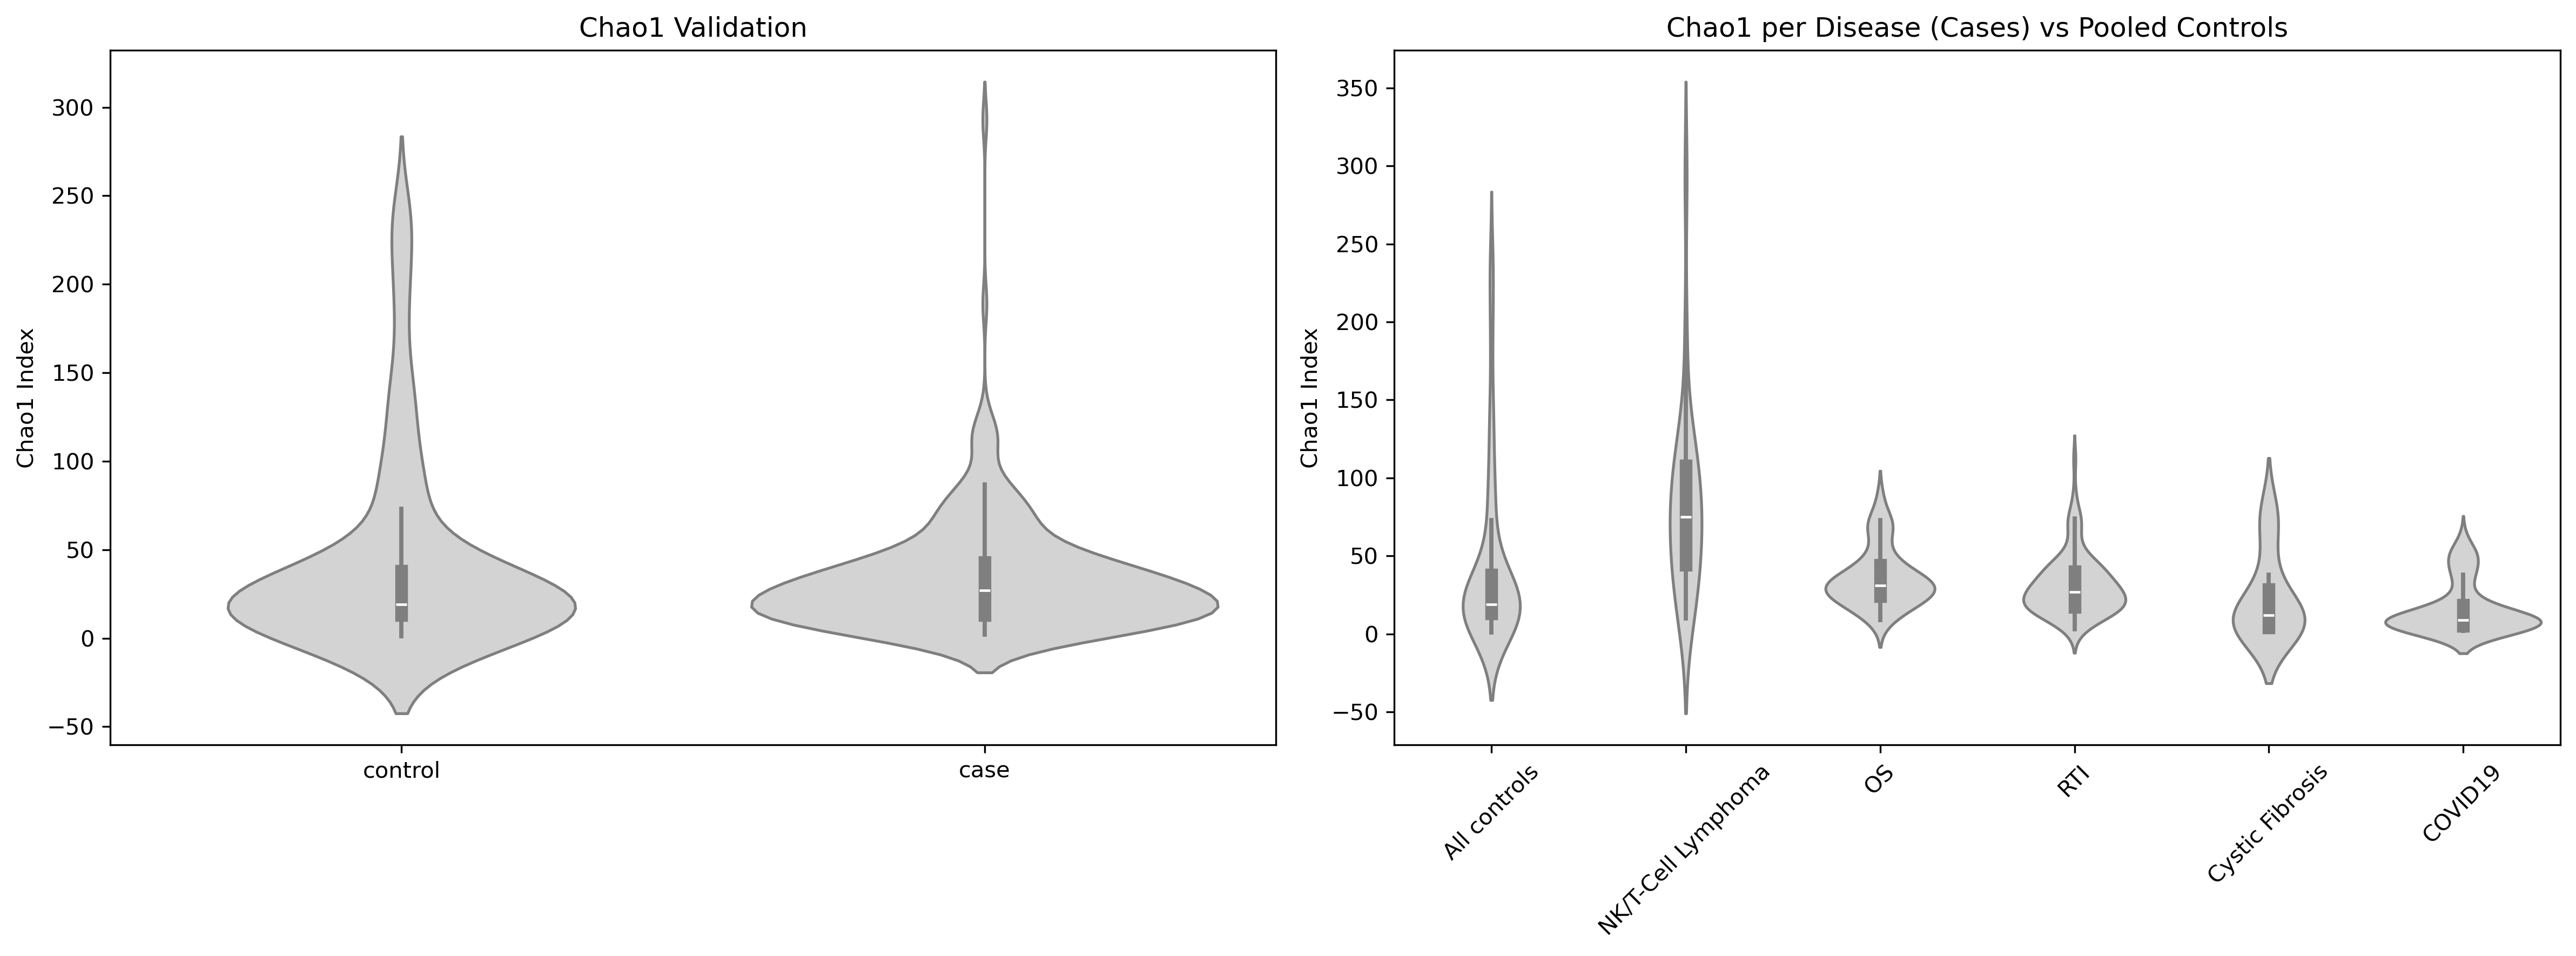

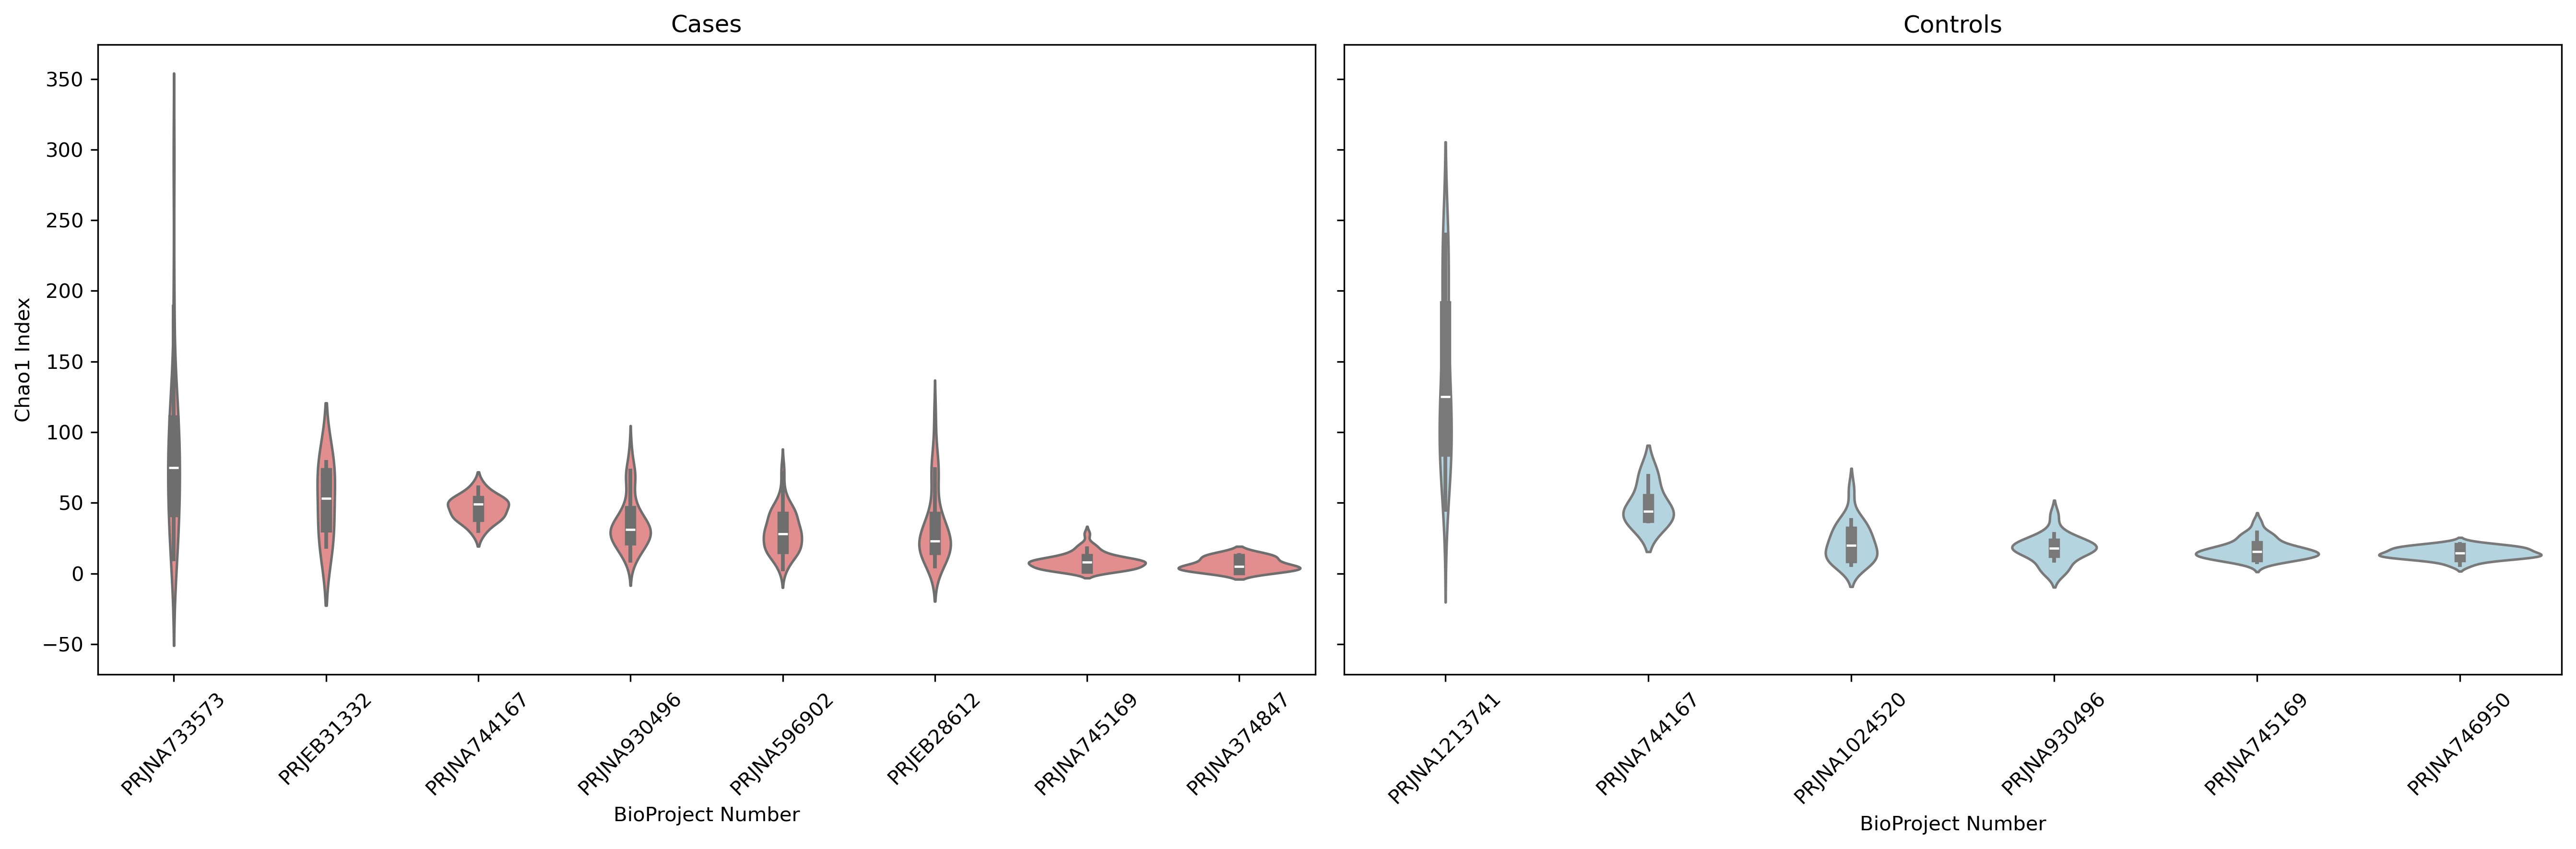

In [46]:
# CHAO1
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

sns.violinplot(
    data=meta_diversity,
    x="Category",
    y="Chao1",
    order=["control", "case"],
    color="lightgray",
    ax=axes[0]
)
axes[0].set(title="Chao1 Validation", xlabel="", ylabel="Chao1 Index")

sns.violinplot(
    data=plot_df_disease,
    x="Group",
    y="Chao1",
    order=["All controls"] + cases.groupby("Disease")["Chao1"].median().sort_values(ascending=False).index.tolist(),
    color="lightgray",
    ax=axes[1]
)
axes[1].set(title="Chao1 per Disease (Cases) vs Pooled Controls", xlabel="", ylabel="Chao1 Index")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=300, sharey=True)

sns.violinplot(
    data=cases,
    x="BioProject.Number",
    y="Chao1",
    order=cases.groupby("BioProject.Number")["Chao1"].median().sort_values(ascending=False).index.tolist(),
    color="lightcoral",
    ax=axes[0]
)
axes[0].set(title="Cases", xlabel="BioProject Number", ylabel="Chao1 Index")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(
    data=controls,
    x="BioProject.Number",
    y="Chao1",
    order=controls.groupby("BioProject.Number")["Chao1"].median().sort_values(ascending=False).index.tolist(),
    color="lightblue",
    ax=axes[1]
)
axes[1].set(title="Controls", xlabel="BioProject Number", ylabel="Chao1 Index")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [47]:
# keep only what we need
sub_Chao1 = meta_diversity[["Category", "Chao1"]].dropna().copy()

Chao1_case_vals = sub_Chao1.loc[sub_Chao1["Category"] == "case", "Chao1"]
Chao1_control_vals = sub_Chao1.loc[sub_Chao1["Category"] == "control", "Chao1"]

u_Chao1, pval_Chao1 = mannwhitneyu(Chao1_case_vals, Chao1_control_vals, alternative="two-sided")

cliffs_delta_Chao1 = (
    (2 * u_Chao1) / (len(Chao1_case_vals) * len(Chao1_control_vals)) - 1
)

results_Chao1 = pd.DataFrame([{
    "Metric": "Chao1",
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(Chao1_case_vals),
    "N_2": len(Chao1_control_vals),
    "Cliffs_delta": cliffs_delta_Chao1,
    "MannWhitney_p": pval_Chao1
}])

# verified with:
# d_Chao1, res_Chao1 = cliffs_delta(Chao1_case_vals, Chao1_control_vals)

results_Chao1


,Metric,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,Chao1,case,control,241,109,0.048765,0.465215
